# Statistical validation of GCC-PHAT

This notebook performs independent calibration/evaluation Monte Carlo experiments for all six microphone pairs. It compares peak diagnostics, nine DOA/risk–coverage variants, three deliberately labelled signal classes, frame lengths, and spherical-versus-plane propagation. The harmonic stress signal is **not** a realistic UAV model. Conditional metrics use successful estimates only; coverage and failures are always reported beside them. No SRP-PHAT, reflections, wind, or motion are used.

In [1]:
from collections import Counter, defaultdict
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from validation.gcc_statistical import (
    CALIBRATION_TRIAL_COUNT, EVALUATION_TRIAL_COUNT, STATISTICAL_BASE_SEED,
    run_complete_gcc_statistical_validation,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
plt.rcParams.update({'figure.figsize': (8, 4.8), 'axes.grid': True})
print('project root:', PROJECT_ROOT)
print('base seed:', STATISTICAL_BASE_SEED)
print('calibration/evaluation trials per configuration:', CALIBRATION_TRIAL_COUNT, EVALUATION_TRIAL_COUNT)

project root: C:\Users\leo\Documents\Stu\APM\7sem\diploma\uav_acoustic_model
base seed: 20260828
calibration/evaluation trials per configuration: 1000 2000


## Full reproducible run

The following cell regenerates all three aggregate CSV files. Calibration and evaluation use different deterministic child seeds.

In [2]:
pair_rows, doa_rows, covariance_rows = run_complete_gcc_statistical_validation(
    pair_output_csv=PROJECT_ROOT / 'results/gcc_pair_error_summary.csv',
    doa_output_csv=PROJECT_ROOT / 'results/gcc_doa_summary.csv',
    covariance_output_csv=PROJECT_ROOT / 'results/gcc_covariance_summary.csv',
)
assert len(pair_rows) == 840
assert len(doa_rows) == 574
assert len(covariance_rows) == 70
assert all(row['calibration_trial_count'] >= 1000 for row in covariance_rows)
assert all(row['evaluation_trial_count'] >= 2000 for row in covariance_rows)
assert all(row['benchmark_name'] == 'Gaussian covariance benchmark' for row in covariance_rows)
assert not any(row['exact_crlb_claimed'] for row in covariance_rows)
print('rows (pair, DOA, covariance):', len(pair_rows), len(doa_rows), len(covariance_rows))
print('total independent realizations:', len(covariance_rows) * (CALIBRATION_TRIAL_COUNT + EVALUATION_TRIAL_COUNT))

rows (pair, DOA, covariance): 840 574 70
total independent realizations: 210000


In [3]:
required = {'study_type', 'signal_model', 'split', 'geometry', 'direction', 'SNR',
            'frame_length', 'pair', 'calibration_trial_count',
            'evaluation_trial_count', 'seed', 'estimator_variant'}
for rows in (pair_rows, doa_rows, covariance_rows):
    assert required <= set(rows[0])
config_pairs = defaultdict(set)
for row in pair_rows:
    key = tuple(row[k] for k in ('study_type', 'signal_model', 'geometry', 'direction', 'SNR', 'frame_length', 'distance_m', 'split'))
    config_pairs[key].add(row['pair'])
assert all(len(pairs) == 6 for pairs in config_pairs.values())
print('study counts, pair rows:', Counter(row['study_type'] for row in pair_rows))
print('study counts, DOA rows:', Counter(row['study_type'] for row in doa_rows))

study counts, pair rows: Counter({'fine_snr': 264, 'signal_comparison': 216, 'frame_length': 192, 'spherical_model': 96, 'direction_check': 72})
study counts, DOA rows: Counter({'fine_snr': 198, 'signal_comparison': 162, 'frame_length': 144, 'direction_check': 54, 'spherical_model': 16})


## Fine-SNR failure boundary

P95 is emphasized because RMSE can be dominated by a small number of correlation-peak swaps. The sampled P95 threshold is a descriptive result on this discrete SNR grid, not an operational threshold.

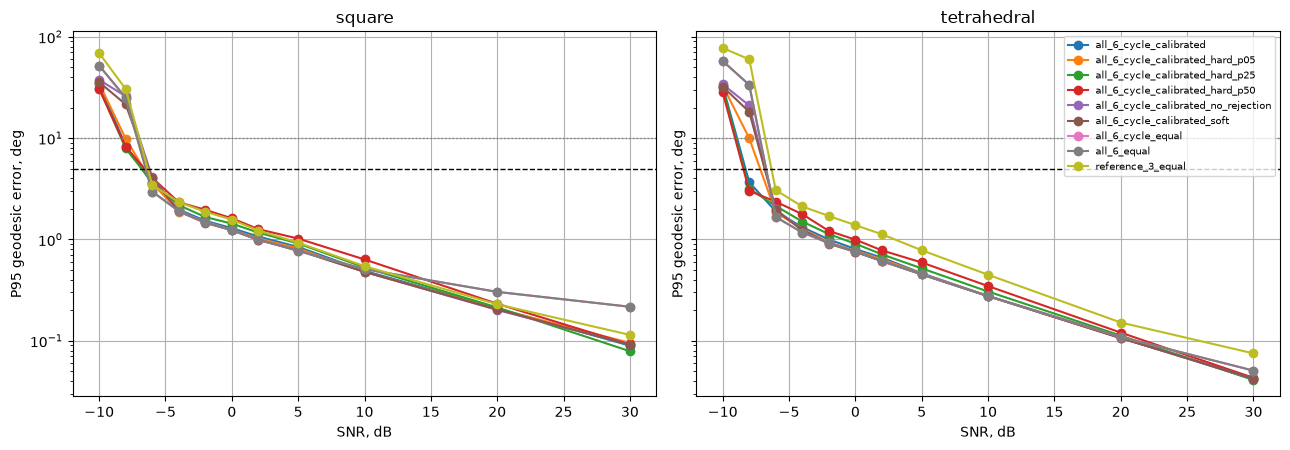

square all_6_cycle_calibrated first sampled SNR P95<5/<10: -6.0 -8.0
square all_6_cycle_calibrated_hard_p05 first sampled SNR P95<5/<10: -6.0 -8.0
square all_6_cycle_calibrated_hard_p25 first sampled SNR P95<5/<10: -6.0 -8.0
square all_6_cycle_calibrated_hard_p50 first sampled SNR P95<5/<10: -6.0 -8.0
square all_6_cycle_calibrated_no_rejection first sampled SNR P95<5/<10: -6.0 -6.0
square all_6_cycle_calibrated_soft first sampled SNR P95<5/<10: -6.0 -6.0
square all_6_cycle_equal first sampled SNR P95<5/<10: -6.0 -6.0
square all_6_equal first sampled SNR P95<5/<10: -6.0 -6.0
square reference_3_equal first sampled SNR P95<5/<10: -6.0 -6.0
tetrahedral all_6_cycle_calibrated first sampled SNR P95<5/<10: -8.0 -8.0
tetrahedral all_6_cycle_calibrated_hard_p05 first sampled SNR P95<5/<10: -6.0 -8.0
tetrahedral all_6_cycle_calibrated_hard_p25 first sampled SNR P95<5/<10: -8.0 -8.0
tetrahedral all_6_cycle_calibrated_hard_p50 first sampled SNR P95<5/<10: -8.0 -8.0
tetrahedral all_6_cycle_calibrat

In [4]:
fine = [r for r in doa_rows if r['study_type'] == 'fine_snr']
variants = sorted({r['estimator_variant'] for r in fine})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, geometry in zip(axes, ('square', 'tetrahedral')):
    for variant in variants:
        rows = sorted((r for r in fine if r['geometry'] == geometry and r['estimator_variant'] == variant), key=lambda r: r['snr_db'])
        ax.semilogy([r['snr_db'] for r in rows], [r['conditional_p95_geodesic_error_deg'] for r in rows], marker='o', label=variant)
    ax.axhline(5, color='k', ls='--', lw=1); ax.axhline(10, color='0.5', ls=':', lw=1)
    ax.set(title=geometry, xlabel='SNR, dB', ylabel='P95 geodesic error, deg')
axes[1].legend(fontsize=7, loc='upper right')
plt.tight_layout(); plt.show()
for geometry in ('square', 'tetrahedral'):
    for variant in variants:
        rows = sorted((r for r in fine if r['geometry'] == geometry and r['estimator_variant'] == variant), key=lambda r: r['snr_db'])
        below5 = [r['snr_db'] for r in rows if r['conditional_p95_geodesic_error_deg'] < 5]
        below10 = [r['snr_db'] for r in rows if r['conditional_p95_geodesic_error_deg'] < 10]
        print(geometry, variant, 'first sampled SNR P95<5/<10:', min(below5), min(below10))

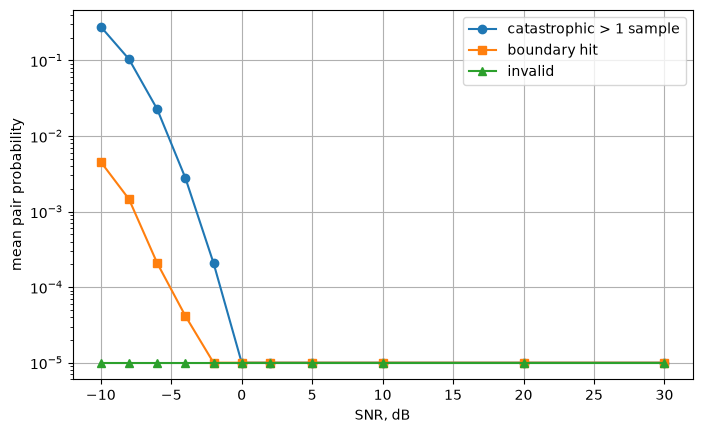

-10 {'catastrophic_outlier_fraction_gt_1_sample': 0.279125, 'boundary_hit_fraction': 0.004541666666666667, 'invalid_fraction': 0.0}
-8 {'catastrophic_outlier_fraction_gt_1_sample': 0.10387500000000001, 'boundary_hit_fraction': 0.0014583333333333334, 'invalid_fraction': 0.0}
-6 {'catastrophic_outlier_fraction_gt_1_sample': 0.02266666666666667, 'boundary_hit_fraction': 0.00020833333333333335, 'invalid_fraction': 0.0}
-4 {'catastrophic_outlier_fraction_gt_1_sample': 0.0027916666666666663, 'boundary_hit_fraction': 4.1666666666666665e-05, 'invalid_fraction': 0.0}
-2 {'catastrophic_outlier_fraction_gt_1_sample': 0.00020833333333333335, 'boundary_hit_fraction': 0.0, 'invalid_fraction': 0.0}
0 {'catastrophic_outlier_fraction_gt_1_sample': 0.0, 'boundary_hit_fraction': 0.0, 'invalid_fraction': 0.0}


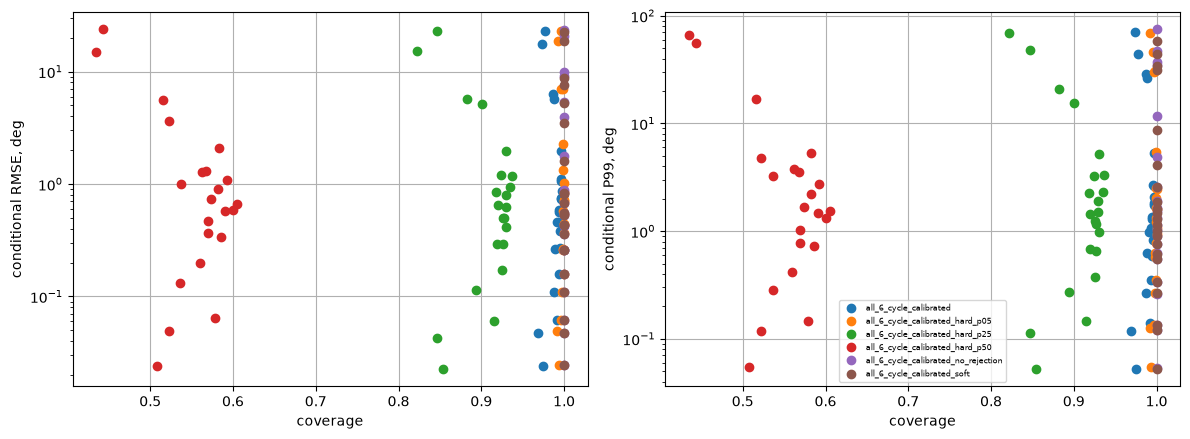

all_6_cycle_calibrated coverage/RMSE/P95/P99/catastrophic/disconnected: 0.9755 20.274918082866144 33.517851149752616 57.72413314284024 0.1707185426592423 0.0245
all_6_cycle_calibrated_hard_p05 coverage/RMSE/P95/P99/catastrophic/disconnected: 0.9942500000000001 20.751498390515433 33.80563551114716 57.4260001046849 0.16653338795990003 0.00575
all_6_cycle_calibrated_hard_p25 coverage/RMSE/P95/P99/catastrophic/disconnected: 0.8342499999999999 19.163349295949033 31.117308226744186 58.569711087343435 0.16825525313190282 0.16575
all_6_cycle_calibrated_hard_p50 coverage/RMSE/P95/P99/catastrophic/disconnected: 0.439 19.417222882404957 29.370365009077318 60.96311444149515 0.18257648192858617 0.5609999999999999
all_6_cycle_calibrated_no_rejection coverage/RMSE/P95/P99/catastrophic/disconnected: 1.0 22.117433474650134 35.743498132238784 61.21908531619614 0.1955 0.0
all_6_cycle_calibrated_soft coverage/RMSE/P95/P99/catastrophic/disconnected: 1.0 20.682465402086088 33.90253104616652 51.3105178966070

In [5]:
fine_pair = [r for r in pair_rows if r['study_type'] == 'fine_snr' and r['split'] == 'evaluation']
snrs = sorted({r['snr_db'] for r in fine_pair})
def mean_at(snr, field):
    values = [r[field] for r in fine_pair if r['snr_db'] == snr]
    return float(np.mean(values))
plt.semilogy(snrs, [max(mean_at(s, 'catastrophic_outlier_fraction_gt_1_sample'), 1e-5) for s in snrs], 'o-', label='catastrophic > 1 sample')
plt.semilogy(snrs, [max(mean_at(s, 'boundary_hit_fraction'), 1e-5) for s in snrs], 's-', label='boundary hit')
plt.semilogy(snrs, [max(mean_at(s, 'invalid_fraction'), 1e-5) for s in snrs], '^-', label='invalid')
plt.xlabel('SNR, dB'); plt.ylabel('mean pair probability'); plt.legend(); plt.show()
for snr in (-10, -8, -6, -4, -2, 0):
    print(snr, {field: mean_at(snr, field) for field in ('catastrophic_outlier_fraction_gt_1_sample', 'boundary_hit_fraction', 'invalid_fraction')})

risk_variants = [v for v in variants if v.startswith('all_6_cycle_calibrated')]
risk_rows = [r for r in fine if r['estimator_variant'] in risk_variants]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for variant in risk_variants:
    rows = [r for r in risk_rows if r['estimator_variant'] == variant]
    axes[0].plot([r['successful_fraction'] for r in rows], [r['conditional_geodesic_rmse_deg'] for r in rows], 'o', label=variant)
    axes[1].plot([r['successful_fraction'] for r in rows], [r['conditional_p99_geodesic_error_deg'] for r in rows], 'o', label=variant)
axes[0].set(xlabel='coverage', ylabel='conditional RMSE, deg', yscale='log')
axes[1].set(xlabel='coverage', ylabel='conditional P99, deg', yscale='log')
axes[1].legend(fontsize=6); plt.tight_layout(); plt.show()
for variant in risk_variants:
    rows = [r for r in risk_rows if r['estimator_variant'] == variant and r['snr_db'] == -10]
    print(variant, 'coverage/RMSE/P95/P99/catastrophic/disconnected:',
          np.mean([r['successful_fraction'] for r in rows]),
          np.mean([r['conditional_geodesic_rmse_deg'] for r in rows]),
          np.mean([r['conditional_p95_geodesic_error_deg'] for r in rows]),
          np.mean([r['conditional_p99_geodesic_error_deg'] for r in rows]),
          np.mean([r['catastrophic_fraction'] for r in rows]),
          np.mean([r['disconnected_graph_failure_fraction'] for r in rows]))

## Signal dependence and confidence diagnostic

These differences are properties of the diagnostic artificial signals and AWGN setup; they are not field-performance claims.

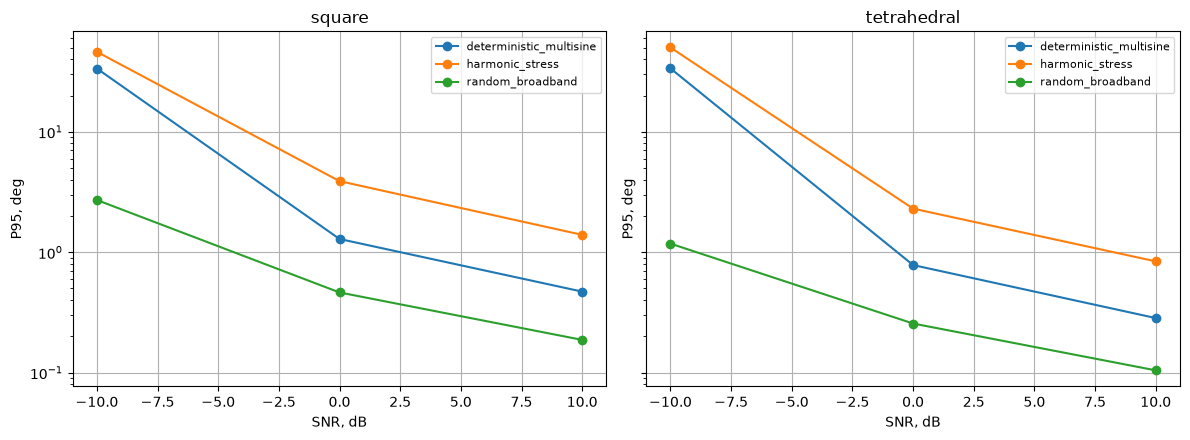

deterministic_multisine mean/range Spearman(confidence, |error|): -0.10988369081873783 -0.3458801059227013 0.15894722894722899
harmonic_stress mean/range Spearman(confidence, |error|): -0.16844130221944087 -0.2613767881675379 -0.07237520837520835
random_broadband mean/range Spearman(confidence, |error|): -0.043672897339564004 -0.132003744003744 0.07280214080214083


In [6]:
signal_rows = [r for r in doa_rows if r['study_type'] == 'signal_comparison' and r['estimator_variant'] == 'all_6_cycle_calibrated']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, geometry in zip(axes, ('square', 'tetrahedral')):
    for signal in sorted({r['signal_model'] for r in signal_rows}):
        rows = sorted((r for r in signal_rows if r['geometry'] == geometry and r['signal_model'] == signal), key=lambda r: r['snr_db'])
        ax.semilogy([r['snr_db'] for r in rows], [r['conditional_p95_geodesic_error_deg'] for r in rows], 'o-', label=signal)
    ax.set(title=geometry, xlabel='SNR, dB', ylabel='P95, deg'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
signal_cov = [r for r in covariance_rows if r['study_type'] == 'signal_comparison']
for signal in sorted({r['signal_model'] for r in signal_cov}):
    rho = [r['mean_confidence_error_spearman'] for r in signal_cov if r['signal_model'] == signal]
    print(signal, 'mean/range Spearman(confidence, |error|):', np.mean(rho), min(rho), max(rho))

## Frame-length study (kept separate from fine-SNR study)

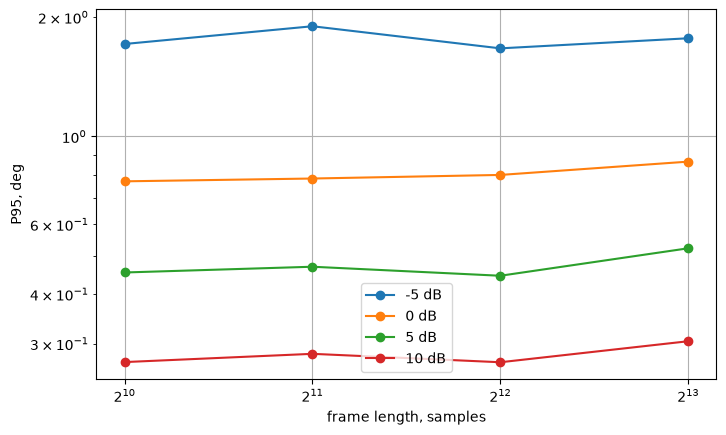

In [7]:
frame_rows = [r for r in doa_rows if r['study_type'] == 'frame_length' and r['estimator_variant'] == 'all_6_cycle_calibrated']
for snr in sorted({r['snr_db'] for r in frame_rows}):
    rows = sorted((r for r in frame_rows if r['snr_db'] == snr), key=lambda r: r['frame_length'])
    plt.plot([r['frame_length'] for r in rows], [r['conditional_p95_geodesic_error_deg'] for r in rows], 'o-', label=f'{snr:g} dB')
plt.xscale('log', base=2); plt.yscale('log'); plt.xlabel('frame length, samples'); plt.ylabel('P95, deg'); plt.legend(); plt.show()

## Empirical covariance

The empirical six-pair covariance is shown as a calibration diagnostic and compared numerically with abstract independent-TDOA and independent-TOA templates. In outlier regimes this is a **Gaussian covariance benchmark**, not an exact CRLB.

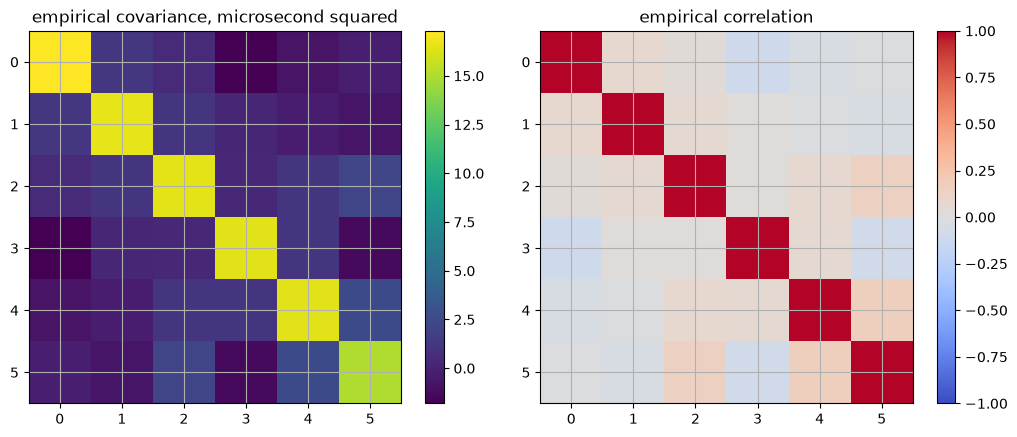

eigenvalues, microsecond squared: [11.952557595346757,14.457116798916676,14.984979741233895,17.588757722840942,19.37416012505545,20.004636332426184]
condition number: 1.6736699382410152
relative Frobenius differences vs independent TDOA / independent TOA: 0.17140402148140021 0.8425973964623472


In [8]:
chosen = next(r for r in covariance_rows if r['study_type'] == 'fine_snr' and r['geometry'] == 'tetrahedral' and r['snr_db'] == 0)
cov = np.asarray(json.loads(chosen['covariance_matrix_us2']))
corr = np.asarray(json.loads(chosen['correlation_matrix']))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
im0 = axes[0].imshow(cov); axes[0].set_title('empirical covariance, microsecond squared'); fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm'); axes[1].set_title('empirical correlation'); fig.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()
print('eigenvalues, microsecond squared:', chosen['eigenvalues_us2'])
print('condition number:', chosen['condition_number'])
print('relative Frobenius differences vs independent TDOA / independent TOA:', chosen['relative_error_vs_independent_tdoa_covariance'], chosen['relative_error_vs_independent_toa_covariance'])

## Spherical signals: measurement error, model mismatch, and DOA bias

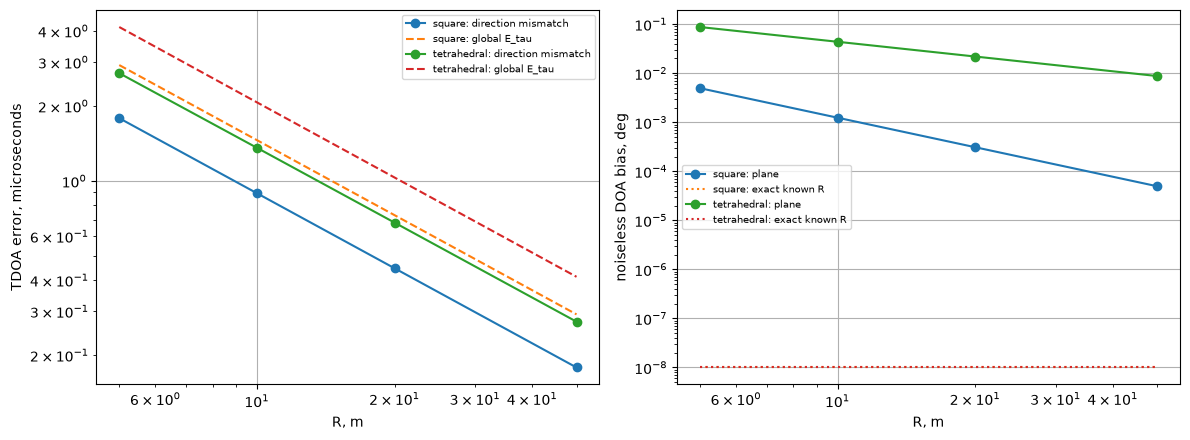

In [9]:
spherical = [r for r in doa_rows if r['study_type'] == 'spherical_model']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for geometry in ('square', 'tetrahedral'):
    rows = sorted((r for r in spherical if r['geometry'] == geometry and r['estimator_variant'] == 'spherical_signal_plane_model'), key=lambda r: r['distance_m'])
    axes[0].loglog([r['distance_m'] for r in rows], [r['direction_specific_plane_model_bias_rms_us'] for r in rows], 'o-', label=f'{geometry}: direction mismatch')
    axes[0].loglog([r['distance_m'] for r in rows], [r['global_E_tau_us'] for r in rows], '--', label=f'{geometry}: global E_tau')
    axes[1].loglog([r['distance_m'] for r in rows], [r['noiseless_plane_doa_bias_deg'] for r in rows], 'o-', label=f'{geometry}: plane')
    exact = sorted((r for r in spherical if r['geometry'] == geometry and r['estimator_variant'] == 'spherical_signal_exact_known_range'), key=lambda r: r['distance_m'])
    axes[1].loglog([r['distance_m'] for r in exact], [max(r['noiseless_exact_doa_bias_deg'], 1e-8) for r in exact], ':', label=f'{geometry}: exact known R')
axes[0].set(xlabel='R, m', ylabel='TDOA error, microseconds'); axes[1].set(xlabel='R, m', ylabel='noiseless DOA bias, deg')
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7); plt.tight_layout(); plt.show()

In [10]:
cycle_after = [r.get('mean_cycle_residual_after_us', np.nan) for r in doa_rows]
assert max(value for value in cycle_after if np.isfinite(value)) < 1e-9
assert all(r['split'] == 'evaluation' for r in doa_rows)
assert all(r['split'] == 'calibration' for r in covariance_rows)
risk = [r for r in doa_rows if r.get('risk_coverage_study')]
assert len(risk) == 372
assert all(r['successful_trial_count'] + r['unsuccessful_trial_count'] == r['evaluation_trial_count'] for r in doa_rows)
assert all(r['conditional_p95_geodesic_error_deg'] <= r['conditional_p99_geodesic_error_deg'] <= r['conditional_p999_geodesic_error_deg'] for r in doa_rows)
for path, expected in ((PROJECT_ROOT / 'results/gcc_pair_error_summary.csv', 840), (PROJECT_ROOT / 'results/gcc_doa_summary.csv', 574), (PROJECT_ROOT / 'results/gcc_covariance_summary.csv', 70)):
    assert path.exists() and sum(1 for _ in path.open(encoding='utf-8')) - 1 == expected
print('All notebook numerical and artifact checks passed.')

All notebook numerical and artifact checks passed.
